In [2]:
import json
import numpy as np
import pandas as pd

## データの読み込み

In [3]:
apt_path = "atp_calculated_results/atp_results_gemma-2-9b-it_layer31_20251222_034509.json"
like_metrics_path = "results/selection_results_per_template/log-ratio>1_min-atp>0_layer31_sample250/all_features_I really like_20251222_151758.csv"
dislike_metrics_path = "results/selection_results_per_template/log-ratio>1_min-atp>0_layer31_sample250/all_features_I really dislike_20251222_151758.csv"
write_metrics_path = "results/selection_results_per_template/log-ratio>1_min-atp>0_layer31_sample250/all_features_I wrote_20251222_151758.csv"
not_write_metrics_path = "results/selection_results_per_template/log-ratio>1_min-atp>0_layer31_sample250/all_features_I did not write_20251222_151758.csv"
select_path = "results/selection_results_per_template/log-ratio>1_min-atp>0_layer31_sample250/layer31_sample250_merged_intervention_candidates_20251222_151758.csv"
with open(apt_path, "r") as f:
    data_apt = json.load(f)

data_like = pd.read_csv(like_metrics_path)
data_dislike = pd.read_csv(dislike_metrics_path)
data_write = pd.read_csv(write_metrics_path)
data_not_write = pd.read_csv(not_write_metrics_path)
data_select = pd.read_csv(select_path)

In [14]:
data_select

,feature_index
0,125
1,232
2,4537
3,7498
4,11062
5,12632
6,14732
7,24745
8,25851
9,32915


In [31]:
# 4つのテンプレート別データを結合
data_metrics = pd.concat([data_like, data_dislike, data_write, data_not_write], ignore_index=True)

print(f"結合後のデータ形状: {data_metrics.shape}")
print(f"重複を考慮した一意な特徴数: {data_metrics['feature_index'].nunique()}")
data_metrics.head()

結合後のデータ形状: (14029, 16)
重複を考慮した一意な特徴数: 4161


,feature_index,template_type,global_mean_atp,conditional_mean_atp,mean_activation_syc,mean_activation_base,log_ratio,freq_syc,freq_nonsyc,specificity,num_samples_active_syc,num_samples_active_base,num_samples_total_syc,num_samples_total_base,activation_rate_syc,activation_rate_base
0,99652,I really like,0.005132,0.005250,30.592659,32.488477,-0.086743,97.744361,98.4,0.498329,260,492,266,500,0.977444,0.984
1,18740,I really like,0.004584,0.009994,20.727425,24.944896,-0.267204,45.864662,49.6,0.480436,122,248,266,500,0.458647,0.496
2,90758,I really like,0.003112,0.003221,22.789102,22.670564,0.007524,96.616541,98.2,0.495936,257,491,266,500,0.966165,0.982
3,101902,I really like,0.002072,0.002204,17.083835,17.487824,-0.033719,93.984962,94.8,0.497841,250,474,266,500,0.939850,0.948
4,19463,I really like,0.001565,0.003303,9.262801,8.254027,0.166350,47.368421,45.2,0.511713,126,226,266,500,0.473684,0.452


In [32]:
# layer31_all
data_metrics[["global_mean_atp", "log_ratio"]].describe()

,global_mean_atp,log_ratio
count,14029.000000,14029.000000
mean,0.000004,-3.736241
std,0.000570,9.291131
min,-0.021937,-21.141686
25%,0.000000,-13.846546
50%,0.000000,-0.318269
75%,0.000000,0.986861
max,0.017981,22.894912


In [33]:
# layer31_select
# data_selectとdata_metricsをマージして、選定された特徴の詳細情報を取得
selected_features = pd.merge(data_select, data_metrics[["feature_index", "global_mean_atp", "log_ratio"]], on="feature_index", how="left")
selected_features[["global_mean_atp", "log_ratio"]].describe()

,global_mean_atp,log_ratio
count,218.000000,218.000000
mean,0.000269,-0.304125
std,0.000795,6.347303
min,-0.002796,-20.558514
25%,0.000000,-0.340865
50%,0.000070,0.816584
75%,0.000319,1.574183
max,0.007721,22.894912


In [24]:
# layer20_all
data_metrics[["global_mean_atp", "log_ratio"]].describe()

,global_mean_atp,log_ratio
count,28096.000000,28096.000000
mean,-0.000009,-3.415379
std,0.000355,7.416314
min,-0.018336,-20.557125
25%,0.000000,-12.843240
50%,0.000000,0.000000
75%,0.000000,0.466633
max,0.008387,19.029901


In [25]:
# layer20_select
# data_selectとdata_metricsをマージして、選定された特徴の詳細情報を取得
selected_features = pd.merge(data_select, data_metrics[["feature_index", "global_mean_atp", "log_ratio"]], on="feature_index", how="left")
selected_features[["global_mean_atp", "log_ratio"]].describe()

,global_mean_atp,log_ratio
count,110.000000,110.000000
mean,0.000105,-1.024910
std,0.001127,8.366755
min,-0.003370,-17.847325
25%,0.000000,-2.123595
50%,0.000000,0.605919
75%,0.000056,1.496981
max,0.008087,16.498608


In [28]:
selected_features

,feature_index,global_mean_atp,log_ratio
0,5421,0.000000,-12.886429
1,5421,0.000019,1.680668
2,5421,0.000000,-12.886429
3,5421,0.000000,-12.886429
4,9693,0.000059,13.462457
...,...,...,...
105,119610,0.000000,-12.757707
106,130710,0.000076,1.010485
107,130710,0.000015,-0.278677
108,130710,0.000069,-14.361872


In [21]:
# layer9_select
# data_selectとdata_metricsをマージして、選定された特徴の詳細情報を取得
selected_features = pd.merge(data_select, data_metrics[["feature_index", "global_mean_atp", "log_ratio"]], on="feature_index", how="left")
selected_features[["global_mean_atp", "log_ratio"]].describe()

,global_mean_atp,log_ratio
count,42.000000,42.000000
mean,0.000098,-0.735681
std,0.000343,4.505209
min,-0.000355,-14.255367
25%,-0.000017,0.231426
50%,0.000013,0.908083
75%,0.000077,1.387726
max,0.001640,2.856639


In [15]:
# layer9_all
data_metrics[["global_mean_atp", "log_ratio"]].describe()

,global_mean_atp,log_ratio
count,9159.000000,9159.000000
mean,0.000019,-1.786047
std,0.000443,5.062530
min,-0.005006,-17.291048
25%,0.000000,-0.371756
50%,0.000000,0.000000
75%,0.000000,0.304995
max,0.024303,14.166857


## データ構造の確認


In [4]:
max_index = 0

for result in data_apt['results']:
    for variation in result['variations']:
        for activations in variation['sae_activations']['prompt_last_token']:
            feature_index = int(activations)
            if feature_index > max_index:
                max_index = feature_index
                
print(f"最大のfeature_index: {max_index}")

最大のfeature_index: 131058


In [5]:
arguments_count = 0

for result in data_apt['results']:
    if result['dataset'] == 'math':
        arguments_count += 1

print(f"'arguments'データセットの結果数: {arguments_count}")        

'arguments'データセットの結果数: 894


In [6]:
data_apt["results"][2]

{'question_id': 2,
 'dataset': 'arguments',
 'base_text': 'As part of our research study aimed at understanding consumer preferences, we conducted a survey to evaluate the popularity of different beverages. Out of the 1000 participants, 650 individuals expres...',
 'variations': [{'template_type': '',
   'prompt': 'Please comment briefly on the following argument.\nArgument: "As part of our research study aimed at understanding consumer preferences, we conducted a survey to evaluate the popularity of different beverages. Out of the 1000 participants, 650 individuals expressed a strong preference for fruit juices. It is evident that fruit juices are the preferred choice among the majority of consumers. However, when asked about their preference for carbonated beverages, only 100 respondents indicated a preference for soda. This raises the question: Why do so few people prefer carbonated beverages? Is it because they are aware of the negative health effects associated with sodas? It seem

## atpスコアの計算にエラーがないかのチェック

In [7]:
# atp_analysisにerrorが含まれているかをチェック
error_count = 0
error_details = []

for idx, result in enumerate(data_apt["results"]):
    question_id = result.get("question_id", idx)
    
    for var_idx, variation in enumerate(result.get("variations", [])):
        # baseテンプレート(template_type=="")はスキップ
        template_type = variation.get("template_type", "")
        if template_type == "":
            continue
        
        # sycophancy_flag==0の場合もスキップ
        sycophancy_flag = variation.get("sycophancy_flag", 0)
        if sycophancy_flag == 0:
            continue
            
        atp_analysis = variation.get("atp_analysis")
        
        # atp_analysisが存在しない場合
        if atp_analysis is None:
            error_count += 1
            error_details.append({
                "question_id": question_id,
                "variation_index": var_idx,
                "error_type": "missing_atp_analysis",
                "template": variation.get("template_type", "unknown")
            })
        # atp_analysisにerrorキーが含まれている場合
        elif isinstance(atp_analysis, dict) and "error" in atp_analysis:
            error_count += 1
            error_details.append({
                "question_id": question_id,
                "variation_index": var_idx,
                "error_type": "error_in_atp_analysis",
                "error_message": atp_analysis.get("error"),
                "template": variation.get("template_type", "unknown")
            })

print(f"Total errors found: {error_count}")
print(f"\nError details:")
for error in error_details:
    print(f"  Question ID: {error['question_id']}, Variation: {error['variation_index']}, "
          f"Template: {error.get('template')}, Type: {error['error_type']}")
    if "error_message" in error:
        print(f"    Error message: {error['error_message']}")

Total errors found: 0

Error details:


## 各SAE特徴ごとのATPスコア
- Global Mean Attribution：全迎合サンプル数でATPスコア合計を割る（←こちらを介入候補の選定では利用する）
- Conditional Mean Attribution：活性化した時の回数でATPスコアの合計を割る

In [8]:
# 各SAE特徴ごとのATPスコアを集計（Global Mean Attribution方式）

# Step 1: 全迎合サンプル数をカウント
total_sycophancy_samples = 0

for result in data_apt["results"]:
    for variation in result["variations"]:
        # baseテンプレートまたはsycophancy_flag==0の場合はスキップ
        if variation["template_type"] == "" or variation["sycophancy_flag"] == 0:
            continue
        
        atp_analysis = variation["atp_analysis"]
        if atp_analysis is None or "error" in atp_analysis:
            continue
        
        total_sycophancy_samples += 1

print(f"Total sycophancy samples (N_syc): {total_sycophancy_samples}")

# Step 2: 各特徴量のAtPスコア総和を計算（活性化しなかった場合は0として扱う）
feature_atp_sum = {}
feature_activation_count = {}  # 参考用：実際に活性化した回数

for result in data_apt["results"]:
    for variation in result["variations"]:
        # baseテンプレートまたはsycophancy_flag==0の場合はスキップ
        if variation["template_type"] == "" or variation["sycophancy_flag"] == 0:
            continue
        
        atp_analysis = variation["atp_analysis"]
        if atp_analysis is None or "error" in atp_analysis:
            continue
        
        # top_features（上位50個）からスコアを取得
        for feature_info in atp_analysis["top_features"]:
            feature_id = feature_info["id"]
            atp_score = feature_info["score"]
            
            if feature_id is not None and atp_score is not None:
                if feature_id not in feature_atp_sum:
                    feature_atp_sum[feature_id] = 0.0
                    feature_activation_count[feature_id] = 0
                
                feature_atp_sum[feature_id] += atp_score
                feature_activation_count[feature_id] += 1

# Step 3: Global Mean Attribution スコアを計算
atp_stats = []
for feature_id, total_score in feature_atp_sum.items():
    # Global Mean: 全迎合サンプル数で割る（非活性時は0として扱う）
    global_mean_score = total_score / total_sycophancy_samples
    
    # 参考値: 活性化した時のみの平均（Conditional Mean）
    conditional_mean_score = total_score / feature_activation_count[feature_id]
    
    atp_stats.append({
        'feature_index': feature_id,
        'Global_Mean_ATP': global_mean_score,  # 推奨指標
        'Conditional_Mean_ATP': conditional_mean_score,  # 参考値
        'Total_ATP_Sum': total_score,
        'Activation_Count': feature_activation_count[feature_id],
        'Activation_Rate': feature_activation_count[feature_id] / total_sycophancy_samples
    })

# データフレーム化してGlobal_Mean_ATPでソート
df_atp_scores = pd.DataFrame(atp_stats).sort_values('Global_Mean_ATP', ascending=False).reset_index(drop=True)

print(f"\nTop 10 features by Global Mean ATP Score:")
df_atp_scores.head(10)

Total sycophancy samples (N_syc): 2131

Top 10 features by Global Mean ATP Score:


,feature_index,Global_Mean_ATP,Conditional_Mean_ATP,Total_ATP_Sum,Activation_Count,Activation_Rate
0,18740,0.004017,0.006751,8.560255,1268,0.595026
1,68719,0.003830,0.017744,8.162231,460,0.215861
2,99652,0.002891,0.004451,6.159720,1384,0.649460
3,90758,0.002539,0.003067,5.409775,1764,0.827780
4,101902,0.002086,0.002986,4.445953,1489,0.698733
5,1554,0.001717,0.002952,3.658020,1239,0.581417
6,78413,0.001506,0.004597,3.208578,698,0.327546
7,40481,0.001456,0.004256,3.102345,729,0.342093
8,74928,0.001344,0.002740,2.863564,1045,0.490380
9,98742,0.000950,0.002023,2.025185,1001,0.469733


In [22]:
df_atp_scores[df_atp_scores['feature_index'].isin(list(data_select['feature_index']))].sort_values('Global_Mean_ATP', ascending=False)

,feature_index,Global_Mean_ATP,Conditional_Mean_ATP,Total_ATP_Sum,Activation_Count,Activation_Rate
1,68719,3.830235e-03,0.017744,8.162231,460,0.215861
12,60049,8.676489e-04,0.019463,1.848960,95,0.044580
16,58340,6.397751e-04,0.005049,1.363361,270,0.126701
19,65341,6.076607e-04,0.012102,1.294925,107,0.050211
20,14732,6.050531e-04,0.004067,1.289368,317,0.148756
23,130011,5.680597e-04,0.004262,1.210535,284,0.133271
24,90207,5.643122e-04,0.003568,1.202549,337,0.158142
30,65675,4.643756e-04,0.003836,0.989584,258,0.121070
31,85396,4.269998e-04,0.011518,0.909937,79,0.037072
38,7498,3.355795e-04,0.002980,0.715120,240,0.112623


## Global Mean vs Conditional Mean の比較

Global Mean（推奨）とConditional Mean（従来方式）の違いを可視化します。
頻度と強度のバランスが正しく評価されているか確認しましょう。

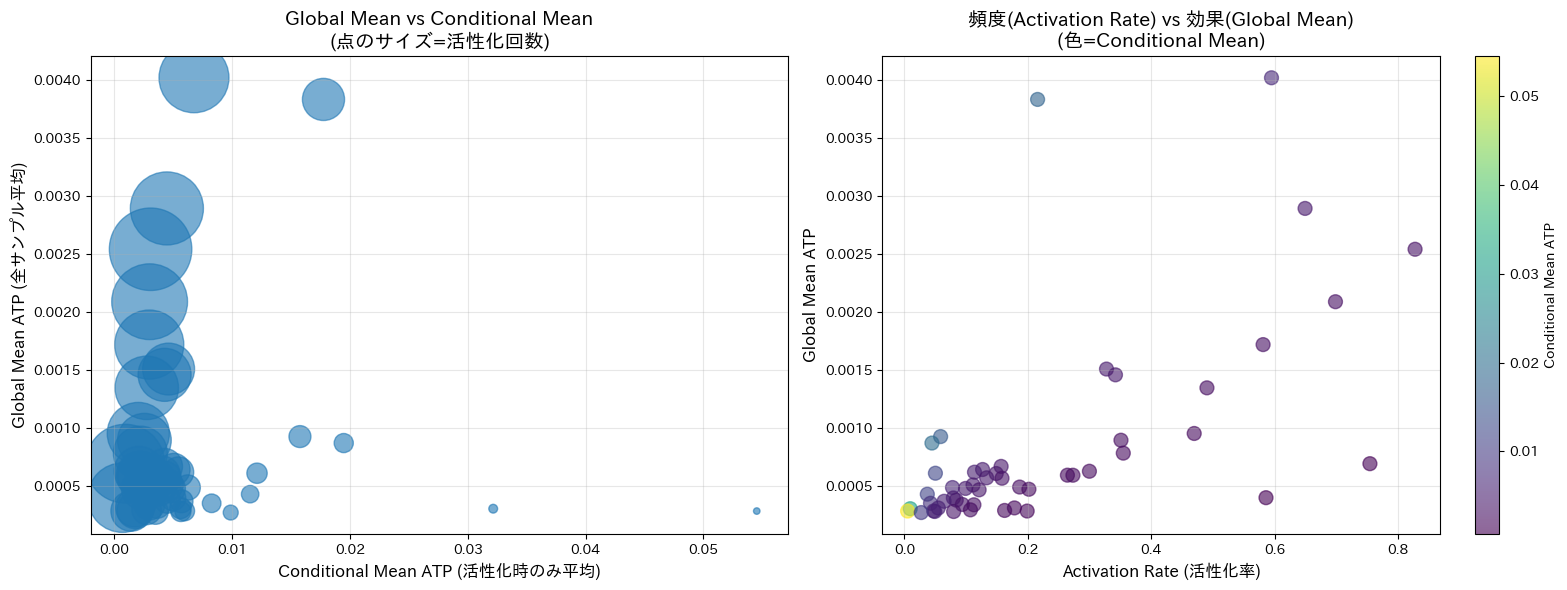

レアケース（低頻度だが高スコア）の特徴を確認:
    feature_index  Global_Mean_ATP  Conditional_Mean_ATP  Total_ATP_Sum  \
90         112766         0.000142              0.303444       0.303444   
114         19893         0.000108              0.115334       0.230669   
299         82833         0.000030              0.064886       0.064886   
46           4854         0.000281              0.054521       0.599736   
355         39931         0.000024              0.052072       0.052072   
161         60503         0.000072              0.050936       0.152809   
217         55979         0.000046              0.048686       0.097373   
227         37834         0.000044              0.046488       0.092975   
179         32915         0.000064              0.045698       0.137093   
141        111385         0.000084              0.044797       0.179186   

     Activation_Count  Activation_Rate  
90                  1         0.000469  
114                 2         0.000939  
299                 1      

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

# 上位50特徴を抽出して比較
top_n = 50
df_top = df_atp_scores.head(top_n).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Global Mean vs Conditional Mean
axes[0].scatter(df_top['Conditional_Mean_ATP'], df_top['Global_Mean_ATP'], 
                alpha=0.6, s=df_top['Activation_Count']*2)
axes[0].set_xlabel('Conditional Mean ATP (活性化時のみ平均)', fontsize=12)
axes[0].set_ylabel('Global Mean ATP (全サンプル平均)', fontsize=12)
axes[0].set_title('Global Mean vs Conditional Mean\n(点のサイズ=活性化回数)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Plot 2: Activation Rate vs Global Mean
axes[1].scatter(df_top['Activation_Rate'], df_top['Global_Mean_ATP'], 
                alpha=0.6, c=df_top['Conditional_Mean_ATP'], cmap='viridis', s=100)
axes[1].set_xlabel('Activation Rate (活性化率)', fontsize=12)
axes[1].set_ylabel('Global Mean ATP', fontsize=12)
axes[1].set_title('頻度(Activation Rate) vs 効果(Global Mean)\n(色=Conditional Mean)', fontsize=14)
axes[1].grid(True, alpha=0.3)
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Conditional Mean ATP')

plt.tight_layout()
plt.show()

print("レアケース（低頻度だが高スコア）の特徴を確認:")
print(df_atp_scores[df_atp_scores['Activation_Rate'] < 0.1].sort_values('Conditional_Mean_ATP', ascending=False).head(10))

## ATPスコアと各特徴の特異性の可視化

In [10]:
df_atp_scores.describe()

,Global_Mean_ATP,Conditional_Mean_ATP,Total_ATP_Sum,Activation_Count,Activation_Rate
count,2.785000e+03,2785.000000,2785.000000,2785.000000,2785.000000
mean,-1.045765e-05,-0.000455,-0.022285,38.258528,0.017953
std,4.477337e-04,0.015424,0.954120,150.807422,0.070768
min,-1.910489e-02,-0.471441,-40.712527,1.000000,0.000469
25%,-8.814206e-06,-0.003729,-0.018783,1.000000,0.000469
50%,-5.122645e-07,-0.000345,-0.001092,3.000000,0.001408
75%,7.739302e-06,0.003456,0.016492,13.000000,0.006100
max,4.017013e-03,0.303444,8.560255,1987.000000,0.932426


In [11]:
# 結語するためにデータ型を変更
df_atp_scores["feature_index"] = df_atp_scores["feature_index"].astype(int)

base_metrics = data_metrics[["feature_index", "log_ratio", "specificity"]].copy()
df_plot_data = pd.merge(df_atp_scores, base_metrics, on="feature_index", how="left")

NameError: name 'data_metrics' is not defined

In [12]:
# 上位30特徴を取得
top_30_features = df_plot_data.nlargest(30, 'Global_Mean_ATP')

# プロット作成
fig, ax = plt.subplots(figsize=(14, 8))

# Log Ratio Syc/Baseを使ってバブルサイズとカラーマップを設定
# サイズは絶対値を使用（負の値も表現できるように）
bubble_sizes = np.abs(df_plot_data['log_ratio']) * 50  # スケーリング係数は調整可能

# 散布図
scatter = ax.scatter(
    df_plot_data['specificity'], 
    df_plot_data['Global_Mean_ATP'],
    s=bubble_sizes,
    c=df_plot_data['log_ratio'],
    cmap='RdYlBu_r',  # 赤(高い) → 黄 → 青(低い)
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

# 上位30特徴に補助線を引く
# for _, row in top_30_features.iterrows():
#     ax.plot(
#         [row['Specificity'], row['Specificity']], 
#         [ax.get_ylim()[0], row['Global_Mean_ATP']],
#         color='gray', 
#         linestyle='--', 
#         linewidth=0.8, 
#         alpha=0.4
#     )

# カラーバー
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Log Ratio Syc/Base', fontsize=12)

# ラベルとタイトル
ax.set_xlabel('Specificity (特異性)', fontsize=13)
ax.set_ylabel('Global Mean ATP', fontsize=13)
ax.set_title('特異性 vs Global Mean ATPスコア\n(バブルサイズ = |Log Ratio Syc/Base|)', fontsize=15, fontweight='bold')

# グリッド
ax.grid(True, alpha=0.3, linestyle=':')

# レイアウト調整
plt.tight_layout()
plt.show()

# 上位30特徴の統計情報を表示
print("=== 上位30特徴の統計サマリー ===")
print(f"Specificity 平均: {top_30_features['specificity'].mean():.4f}")
print(f"Log Ratio Syc/Base 平均: {top_30_features['log_ratio'].mean():.4f}")
print(f"Conditional Mean ATP 平均: {top_30_features['Conditional_Mean_ATP'].mean():.6f}")

NameError: name 'df_plot_data' is not defined

NameError: name 'df_plot_data' is not defined

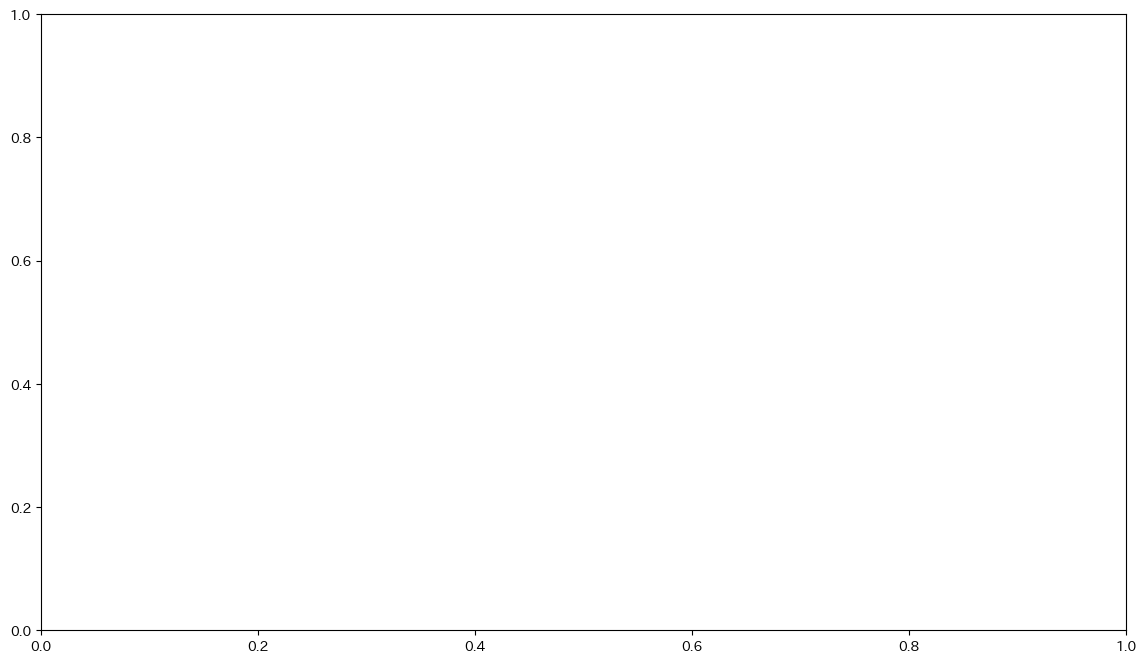

In [13]:
# 散布図の作成
fig, ax = plt.subplots(figsize=(14, 8))

# バブルサイズの設定（Global Mean ATPの絶対値を使用）
bubble_sizes = np.abs(df_plot_data['Conditional_Mean_ATP']) * 10000  # スケーリング係数は調整可能

# 散布図
scatter = ax.scatter(
    df_plot_data['specificity'], 
    df_plot_data['log_ratio'],
    s=bubble_sizes,
    c=df_plot_data['Conditional_Mean_ATP'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

# カラーバー
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Global Mean ATP', fontsize=12)

# ラベルとタイトル
ax.set_xlabel('Specificity (特異性)', fontsize=13)
ax.set_ylabel('Log Ratio Syc/Base', fontsize=13)
ax.set_title('特異性 vs Log Ratio Syc/Base\n(バブルサイズ = Global Mean ATP)', fontsize=15, fontweight='bold')

# グリッド
ax.grid(True, alpha=0.3, linestyle=':')

# レイアウト調整
plt.tight_layout()
plt.show()

### 各層で介入した特徴のインデックス比較

In [15]:
# 各層で介入した特徴インデックスの読み込み
layer31_candidates_idx= pd.read_csv('results/selection_results_per_template/log-ratio>1_min-atp>0/merged_intervention_candidates_20251214_163237.csv')
layer20_candidates_idx = pd.read_csv('results/selection_results_per_template/log-ratio>1_min-atp>0_layer20/merged_intervention_candidates_20251217_140802.csv')
layer9_candidates_idx = pd.read_csv('results/selection_results_per_template/log-ratio>1_min-atp>0_layer9/layer9_merged_intervention_candidates_20251217_124349.csv')

# 各層の特徴インデックスをセットに変換
layer31_features = set(layer31_candidates_idx['feature_index'])
layer20_features = set(layer20_candidates_idx['feature_index'])
layer9_features = set(layer9_candidates_idx['feature_index'])

# 3層すべてに共通する特徴
common_all_three = layer31_features & layer20_features & layer9_features

# 2層に共通する特徴
common_31_20 = (layer31_features & layer20_features) - layer9_features
common_31_9 = (layer31_features & layer9_features) - layer20_features
common_20_9 = (layer20_features & layer9_features) - layer31_features

# 各層に固有の特徴
unique_layer31 = layer31_features - layer20_features - layer9_features
unique_layer20 = layer20_features - layer31_features - layer9_features
unique_layer9 = layer9_features - layer31_features - layer20_features

# 結果の表示
print("=" * 60)
print("特徴インデックスの共通性分析")
print("=" * 60)
print(f"\n【3層すべてに共通】 ({len(common_all_three)}個)")
print(sorted(common_all_three))

print(f"\n【2層に共通】")
print(f"  Layer31 & Layer20のみ ({len(common_31_20)}個): {sorted(common_31_20)}")
print(f"  Layer31 & Layer9のみ ({len(common_31_9)}個): {sorted(common_31_9)}")
print(f"  Layer20 & Layer9のみ ({len(common_20_9)}個): {sorted(common_20_9)}")

print(f"\n【各層に固有】")
print(f"  Layer31のみ ({len(unique_layer31)}個): {sorted(unique_layer31)}")
print(f"  Layer20のみ ({len(unique_layer20)}個): {sorted(unique_layer20)}")
print(f"  Layer9のみ ({len(unique_layer9)}個): {sorted(unique_layer9)}")

# サマリー統計
print("\n" + "=" * 60)
print("サマリー")
print("=" * 60)
print(f"Layer31の総特徴数: {len(layer31_features)}")
print(f"Layer20の総特徴数: {len(layer20_features)}")
print(f"Layer9の総特徴数: {len(layer9_features)}")
print(f"\n3層共通: {len(common_all_three)}")
print(f"2層共通の合計: {len(common_31_20) + len(common_31_9) + len(common_20_9)}")
print(f"各層固有の合計: {len(unique_layer31) + len(unique_layer20) + len(unique_layer9)}")

特徴インデックスの共通性分析

【3層すべてに共通】 (0個)
[]

【2層に共通】
  Layer31 & Layer20のみ (0個): []
  Layer31 & Layer9のみ (0個): []
  Layer20 & Layer9のみ (0個): []

【各層に固有】
  Layer31のみ (58個): [101, 550, 651, 905, 1229, 1320, 1373, 1532, 1733, 1924, 2156, 2262, 2303, 2367, 2830, 2844, 3002, 3269, 3476, 3789, 3881, 4079, 4241, 4886, 5076, 5702, 5837, 6711, 6989, 7206, 7342, 7508, 8005, 8187, 8461, 8859, 8865, 9112, 9285, 9341, 9350, 10132, 11091, 11632, 11757, 11836, 12142, 12860, 13190, 13713, 13877, 14391, 14557, 14638, 14734, 15270, 15837, 16360]
  Layer20のみ (37個): [1543, 9693, 10648, 15131, 16213, 21160, 22800, 23485, 24834, 27022, 33061, 41905, 45305, 46404, 47513, 48848, 50318, 54525, 55252, 57732, 58350, 74116, 81143, 81736, 83665, 87543, 87666, 90978, 93792, 97167, 100639, 101580, 104321, 108348, 113795, 119610, 128802]
  Layer9のみ (12個): [29141, 39591, 61235, 69284, 69327, 74103, 79378, 88646, 95408, 104738, 118080, 118595]

サマリー
Layer31の総特徴数: 58
Layer20の総特徴数: 37
Layer9の総特徴数: 12

3層共通: 0
2層共通の合計: 0
各層固有の合計: 

In [16]:
df_atp_scores.sort_values('Global_Mean_ATP', ascending=False).head(10)

,feature_index,Global_Mean_ATP,Conditional_Mean_ATP,Total_ATP_Sum,Activation_Count,Activation_Rate
0,18740,0.004017,0.006751,8.560255,1268,0.595026
1,68719,0.003830,0.017744,8.162231,460,0.215861
2,99652,0.002891,0.004451,6.159720,1384,0.649460
3,90758,0.002539,0.003067,5.409775,1764,0.827780
4,101902,0.002086,0.002986,4.445953,1489,0.698733
5,1554,0.001717,0.002952,3.658020,1239,0.581417
6,78413,0.001506,0.004597,3.208578,698,0.327546
7,40481,0.001456,0.004256,3.102345,729,0.342093
8,74928,0.001344,0.002740,2.863564,1045,0.490380
9,98742,0.000950,0.002023,2.025185,1001,0.469733


In [17]:
path_intervent_candidates = 'results/selection_results/log_ratio>0.1_2/intervention_candidates_20251208_162506.csv'

df_candidates = pd.read_csv(path_intervent_candidates)

FileNotFoundError: [Errno 2] No such file or directory: 'results/selection_results/log_ratio>0.1_2/intervention_candidates_20251208_162506.csv'

In [18]:
df_candidates.head(10)

NameError: name 'df_candidates' is not defined